# Headless Quick View — using Quantum Metal without the Qt GUI

This notebook shows how to design and **view** components in Quantum Metal **without launching the Qt desktop GUI**. The full API works headlessly in a plain Python interpreter or in cloud notebook environments like Jupyter, Colab, and Binder where Qt isn't available or wanted.

## What you'll learn

1. How to build a design programmatically — same API as the GUI workflow
2. How to use `qm.view(design)` to render a design to a matplotlib figure inline
3. How to customise the view: filter components, hide layers, render into existing axes
4. How to save the rendered design to a file

## When to use this workflow

- You're running on a server / cloud notebook (Colab, Binder, JupyterHub) where PySide6 isn't installed.
- You're scripting a parameter sweep and just want to verify the geometry looks right.
- You're embedding Quantum Metal in a larger pipeline (CI, automated optimization, papers/figures).

If you want the **interactive editor** with click-to-select components, dockable panels, and live option editing, use `qm.MetalGUI(design)` instead. That requires a local installation with PySide6.

## Setup

We force matplotlib's `Agg` backend before any plot calls so the notebook works on headless runners. In a normal Jupyter session you can skip this — Jupyter picks an inline-friendly backend automatically.

In [1]:
import matplotlib

# matplotlib.use("Agg")  # only needed when not in Jupyter

import qiskit_metal as qm
from qiskit_metal import Dict
from qiskit_metal.designs import DesignPlanar
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround

09:27PM 36s WARNING [_maybe_warn_lite_flip]: [FutureWarning] quantum-metal v0.7.0 will move PySide6, qdarkstyle, pyaedt, pyEPR-quantum, and gmsh out of base dependencies into opt-in extras. To preserve the current v0.6.x install behaviour, run `pip install 'quantum-metal[full]'` before upgrading. See ROADMAP.md and docs/migration-to-v0.7.0.rst for details. Set QISKIT_METAL_SUPPRESS_LITE_FLIP_WARNING=1 to silence.


## Build a small design programmatically

Same API as the GUI workflow — no Qt window is created.

In [2]:
design = DesignPlanar()

# A transmon qubit with one coupling pad
TransmonPocket(
    design,
    "Q1",
    options=Dict(
        pos_x="0mm",
        pos_y="0mm",
        connection_pads=Dict(
            a=Dict(loc_W="+1", loc_H="+1"),
        ),
    ),
)

# A ground termination next to it
OpenToGround(
    design,
    "G1",
    options=Dict(pos_x="1mm", pos_y="0mm"),
)

print("Components in design:", list(design.components.keys()))

Components in design: ['Q1', 'G1']


## View the design

`qm.view(design)` returns a `matplotlib.figure.Figure`. In Jupyter it will display inline; you can also save it or further customise it like any other matplotlib figure.

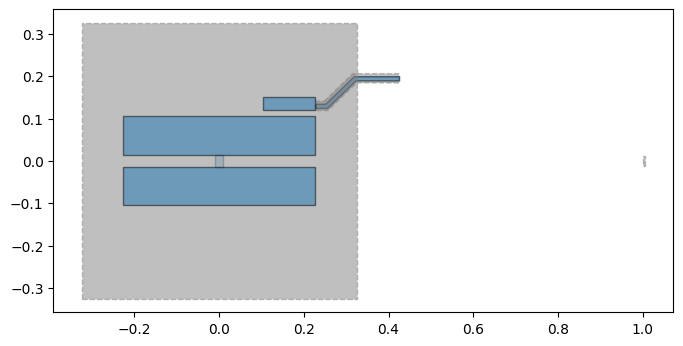

In [3]:
fig = qm.view(design) # shows automatically in jupyter
fig # You can also use "display(fig)"

## Iterating on the design

Changing a component's options is the same workflow as in the GUI — but you get a new `Figure` instead of an updated Qt canvas. Component objects are accessible by name via `design.components`.

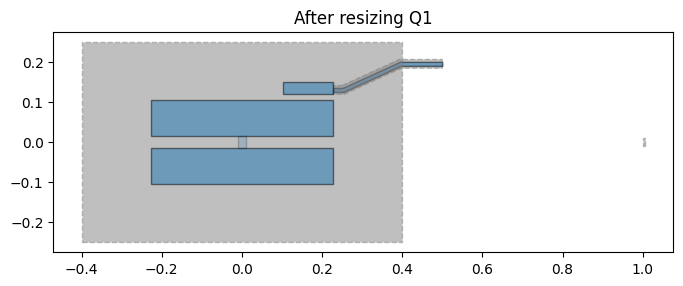

In [4]:
# Change Q1's pocket dimensions and re-render — no Qt window
design.components["Q1"].options.pocket_width = "800um"
design.components["Q1"].options.pocket_height = "500um"
design.rebuild()

fig = qm.view(design, title="After resizing Q1")
fig

## Customising the view

### Filter to specific components

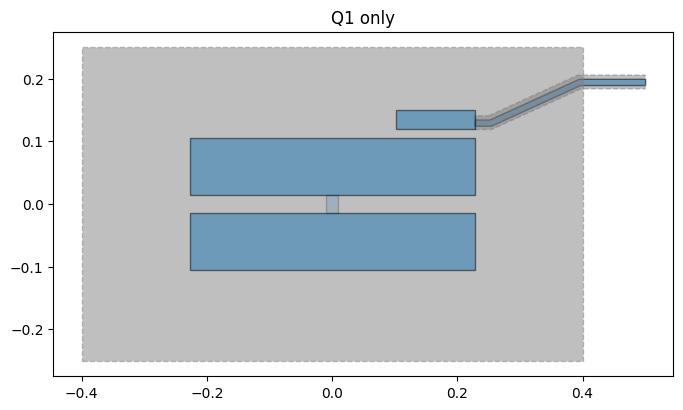

In [5]:
fig = qm.view(design, components=["Q1"], title="Q1 only")
fig

### Custom figure size

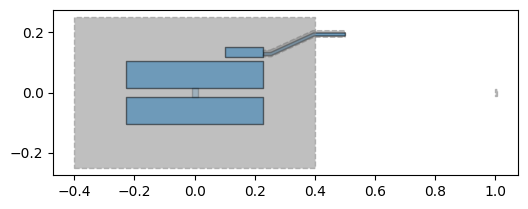

In [6]:
fig = qm.view(design, figsize=(6, 4))
fig

### Side-by-side in a multi-panel figure

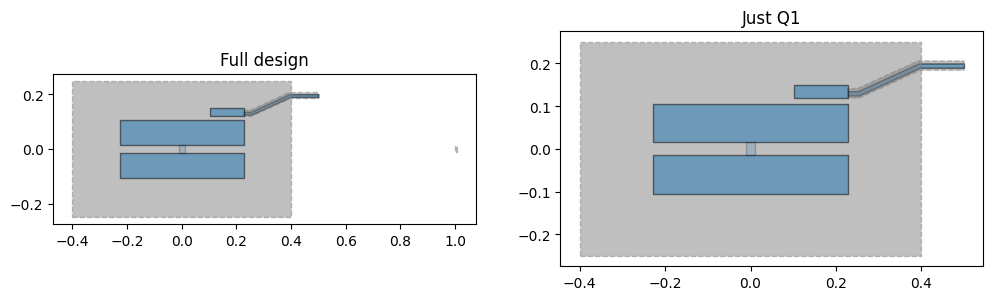

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
qm.view(design, ax=axes[0], title="Full design")
qm.view(design, ax=axes[1], components=["Q1"], title="Just Q1")
fig

## A coupled two-qubit design

The `components=` argument to `qm.view` lets you highlight any subset of the design — useful for inspecting individual qubits or the coupler in isolation. Here we build two `TransmonPocket` qubits connected by a `RouteStraight` bus coupler and then view them together and separately.

In [8]:
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight

design2 = DesignPlanar()
design2.chips.main.size['size_x'] = '3mm'
design2.chips.main.size['size_y'] = '2mm'

TransmonPocket(
    design2, 'Q1',
    options=Dict(
        pos_x='-0.75mm',
        pos_y='0mm',
        pad_width='425um',
        pocket_height='650um',
        connection_pads=Dict(
            readout=Dict(loc_W=+1, loc_H=+1, pad_width='200um'),
        ),
    ),
)

TransmonPocket(
    design2, 'Q2',
    options=Dict(
        pos_x='0.75mm',
        pos_y='0mm',
        pad_width='425um',
        pocket_height='650um',
        connection_pads=Dict(
            readout=Dict(loc_W=-1, loc_H=+1, pad_width='200um'),
        ),
    ),
)

RouteStraight(
    design2, 'coupler',
    Dict(
        pin_inputs=Dict(
            start_pin=Dict(component='Q1', pin='readout'),
            end_pin=Dict(component='Q2', pin='readout'),
        ),
    ),
)

print('Components:', list(design2.components.keys()))

Components: ['Q1', 'Q2', 'coupler']


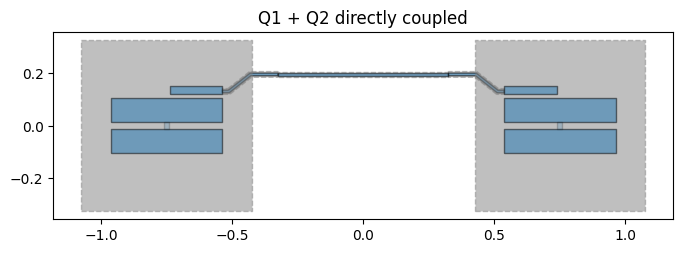

In [9]:
fig = qm.view(design2, title='Q1 + Q2 directly coupled')
fig

### Highlight individual components

Pass `components=[...]` with any subset of component names. Everything else is hidden, so you can focus on one qubit, one coupler, or any combination.

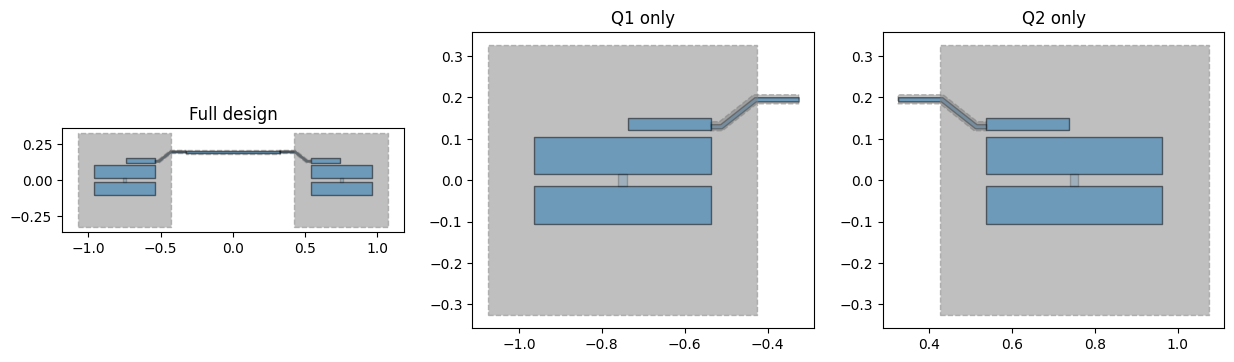

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
qm.view(design2, ax=axes[0], title='Full design')
qm.view(design2, ax=axes[1], components=['Q1'], title='Q1 only')
qm.view(design2, ax=axes[2], components=['Q2'], title='Q2 only')
fig

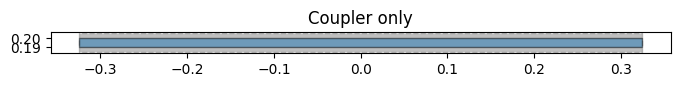

In [11]:
# The coupler on its own — useful for checking routing geometry
fig = qm.view(design2, components=['coupler'], title='Coupler only')
fig

### Highlight a subset — headless equivalent of `gui.highlight_components()`

In the Qt GUI you'd call `gui.highlight_components(["Q1", "Q2"])` to focus on specific components. The headless equivalent is the same `components=` argument — pass any combination of component names and everything else is hidden.

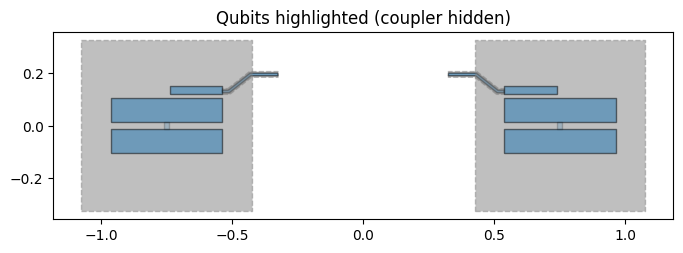

In [12]:
# Show both qubits together, hide the coupler
fig = qm.view(design2, components=["Q1", "Q2"], title="Qubits highlighted (coupler hidden)")
fig

## Interactive pan & zoom in JupyterLab

`qm.view()` returns a standard matplotlib `Figure` that works with any backend.
Switch to the `widget` backend (powered by [ipympl](https://matplotlib.org/ipympl/))
for interactive pan, zoom, and mouse navigation directly inside JupyterLab.

**Install `ipympl` if you do not have it:**

```bash
pip install "quantum-metal[jupyter]"   # full dev install — already includes ipympl
pip install ipympl                      # standalone
```

### Two rules for switching backends

1. **Switch before you create any figures.** `%matplotlib widget` registers a new
   canvas type; figures already open stay on the old backend and won't become
   interactive. Re-run the plot cells after switching.
2. **Qt and ipympl cannot share a kernel.** If Qt has been initialised in this
   kernel session (e.g. you imported `MetalGUI` earlier, even in a different
   notebook), the widget backend will silently accept the switch but figures
   will still render statically. In that case **restart the kernel** and run
   `%matplotlib widget` as the very first cell.

> This notebook never imports `MetalGUI`, so the widget backend works here
> without a kernel restart. Notebooks that do use `MetalGUI` (e.g. 1.2, 1.3)
> cannot switch to `widget` mid-session — use this notebook for interactive
> exploration instead.


In [13]:
# Run this cell FIRST — before any qm.view() or plt calls.
# Re-run the plot cells below after switching to see the interactive canvas.
try:
    import ipympl  # noqa: F401
    get_ipython().run_line_magic("matplotlib", "widget")
    import matplotlib
    print(f"Backend switched to: {matplotlib.get_backend()}")
    print("Re-run the plot cells below to get interactive figures.")
except ImportError:
    get_ipython().run_line_magic("matplotlib", "inline")
    print("ipympl not installed — static inline figures only.")
    print('Install: pip install "quantum-metal[jupyter]"')
except Exception as e:
    get_ipython().run_line_magic("matplotlib", "inline")
    print(f"Could not switch to widget backend ({e}).")
    print("If Qt is active in this kernel, restart and run this cell first.")


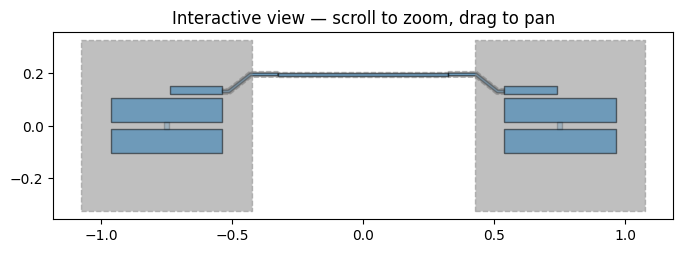

In [15]:
# Now qm.view() returns an interactive figure: scroll to zoom, drag to pan
fig = qm.view(design2, title="Interactive view — scroll to zoom, drag to pan")
fig

In [16]:
# Switch back to static inline rendering when you're done exploring
%matplotlib inline

## Save to a file

Any `matplotlib.figure.Figure` method works — `savefig` to PNG/PDF/SVG, embed in a paper, etc.

In [18]:
fig = qm.view(design)
fig.savefig("my_design.png", dpi=150, bbox_inches="tight")
print("Saved my_design.png")

Saved my_design.png


## What about HFSS / Q3D / GDS?

All non-Qt renderers work headlessly too:

- **GDS export** — `QGDSRenderer(design).export_to_gds("out.gds")` works without Qt.
- **HFSS / Q3D** — the *renderer* doesn't require Qt, but it does require Ansys AEDT installed on the machine running the script. On a cloud notebook without Ansys, you can still build the design and export GDS / visualise with `qm.view`; you just can't run the live solve.
- **Analyses** — every module in `qiskit_metal.analyses` is pure Python (numpy / scipy / qutip) and works headlessly.

## Next steps

- See `docs/headless-usage.rst` for the full reference.
- See the [1.2 Quick start](./1.2-Quick-start.ipynb) notebook for a tour of the GUI-driven workflow.
- For interactive pan/zoom in Jupyter without Qt, install `ipympl` and run `%matplotlib widget` at the top of your notebook.

## What's next

* Browse [1.1 Bird's eye view](./1.1-Bird's-eye-view-of-Qiskit-Metal.ipynb) and [1.2 Quick start](./1.2-Quick-start.ipynb) — they use `MetalGUI` for visualisation but every concept transfers; just replace `gui.rebuild()` with `qm.view(design)`. The GUI-screenshots in those tutorials give you a sense of what the desktop experience looks like.
* See the **2 From components to chip** folder for multi-qubit designs and CPW routing. The same `qm.view(design)` call works for any of them — pass `figsize=(12, 12)` for chip-scale views.
* For programmatic GDS export (no Qt or Ansys required), use the `QGDSRenderer`:

  ```python
  from qiskit_metal.renderers.renderer_gds.gds_renderer import QGDSRenderer
  gds = QGDSRenderer(design)
  gds.export_to_gds("my_chip.gds")
  ```

* Read the full reference in [`docs/headless-usage.rst`](../../docs/headless-usage.rst) for all of `qm.view`'s options, the `[gui]`/`[ansys]`/`[fem]` install extras, and the roadmap for a future richer interactive viewer.